# ICML Topic Modelling — LDA Analysis (1987–2016)


In [52]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud
from collections import Counter
# Download required NLTK resources
for resource in ['punkt', 'punkt_tab', 'stopwords', 'wordnet', 'omw-1.4']:
    nltk.download(resource, quiet=True)
print("All imports successful.")

All imports successful.


---
## 1.1 — Section 1: Data Cleaning
**Steps:** loading the dataset, removing duplicates, handling missing/placeholder abstracts, and constructing a unified text column.

In [53]:
# Load the dataset
df = pd.read_csv('articles.csv')

print(f"Original shape: {df.shape}")
print(f"\nColumn data types:")
print(df.dtypes)
print(f"\nMissing values per column:")
print(df.isnull().sum())

Original shape: (6560, 7)

Column data types:
id             int64
year           int64
title         object
event_type    object
pdf_name      object
abstract      object
paper_text    object
dtype: object

Missing values per column:
id               0
year             0
title            0
event_type    4819
pdf_name         0
abstract         0
paper_text       0
dtype: int64


In [54]:
# --- Step 1: Remove duplicate rows ---
# Clean up duplicate rows from the dataset
duplicate_count = df.duplicated().sum()
df = df.drop_duplicates()

print(f"Dropped {duplicate_count} duplicates.")
print(f"New data shape: {df.shape}")

Dropped 0 duplicates.
New data shape: (6560, 7)


In [55]:
# Clean and combine abstract + paper text (short, readable version)
null_count = df['abstract'].isna().sum()
missing_mask = df['abstract'].fillna('').str.strip().isin(['', 'Abstract Missing'])
print(f"Placeholders/empty: {missing_mask.sum()} | Nulls: {null_count}")

fallback = df['paper_text'].fillna('').str.split().str[:500].str.join(' ')
df['text'] = df['abstract'].fillna('').str.strip()
df.loc[missing_mask, 'text'] = fallback[missing_mask]

# Keep only rows with meaningful text
df = df[df['text'].str.len() > 20].copy()

print(f"\nData cleanup complete. Current shape: {df.shape}")
print(f"Missing values left in 'text': {df['text'].isna().sum()}")

Placeholders/empty: 3317 | Nulls: 0

Data cleanup complete. Current shape: (6560, 8)
Missing values left in 'text': 0


In [56]:
# Reset index after cleaning
df = df.reset_index(drop=True)
print("Sample cleaned text (first paper):")
print(df['text'].iloc[0][:300], '...')

Sample cleaned text (first paper):
767 SELF-ORGANIZATION OF ASSOCIATIVE DATABASE AND ITS APPLICATIONS Hisashi Suzuki and Suguru Arimoto Osaka University, Toyonaka, Osaka 560, Japan ABSTRACT An efficient method of self-organizing associative databases is proposed together with applications to robot eyesight systems. The proposed datab ...


---
## 1.1 — Section 2: Exploratory Analysis

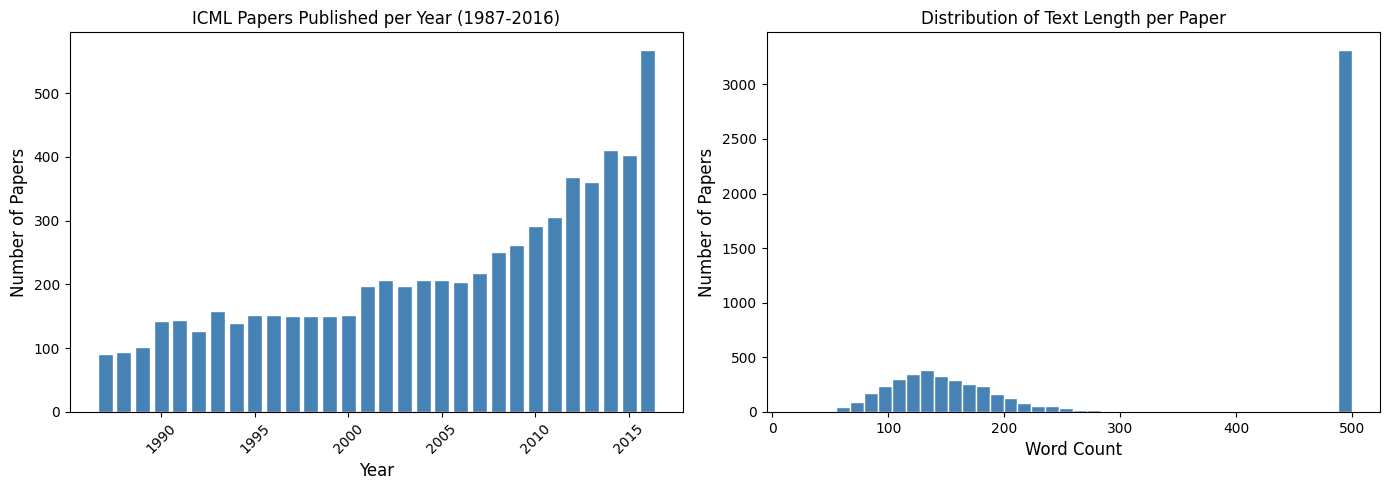


Year range: 1987 - 2016

Text length statistics (words):
count    6560.0
mean      324.8
std       179.8
min        19.0
25%       141.0
50%       500.0
75%       500.0
max       500.0
Name: word_count, dtype: float64


In [57]:
# Quick EDA: papers per year + text length
year_counts = df['year'].value_counts().sort_index()
df['word_count'] = df['text'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: papers per year
axes[0].bar(
    year_counts.index,
    year_counts.values,
    color='steelblue',
    edgecolor='white'
)
axes[0].set_xlabel('Year', fontsize=12)
axes[0].set_ylabel('Number of Papers', fontsize=12)
axes[0].set_title('ICML Papers Published per Year (1987-2016)', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: word-count distribution
axes[1].hist(
    df['word_count'],
    bins=40,
    color='steelblue',
    edgecolor='white'
)
axes[1].set_xlabel('Word Count', fontsize=12)
axes[1].set_ylabel('Number of Papers', fontsize=12)
axes[1].set_title('Distribution of Text Length per Paper', fontsize=12)

plt.tight_layout()
plt.savefig('eda_paper_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nYear range: {df['year'].min()} - {df['year'].max()}")
print('\nText length statistics (words):')
print(df['word_count'].describe().round(1))

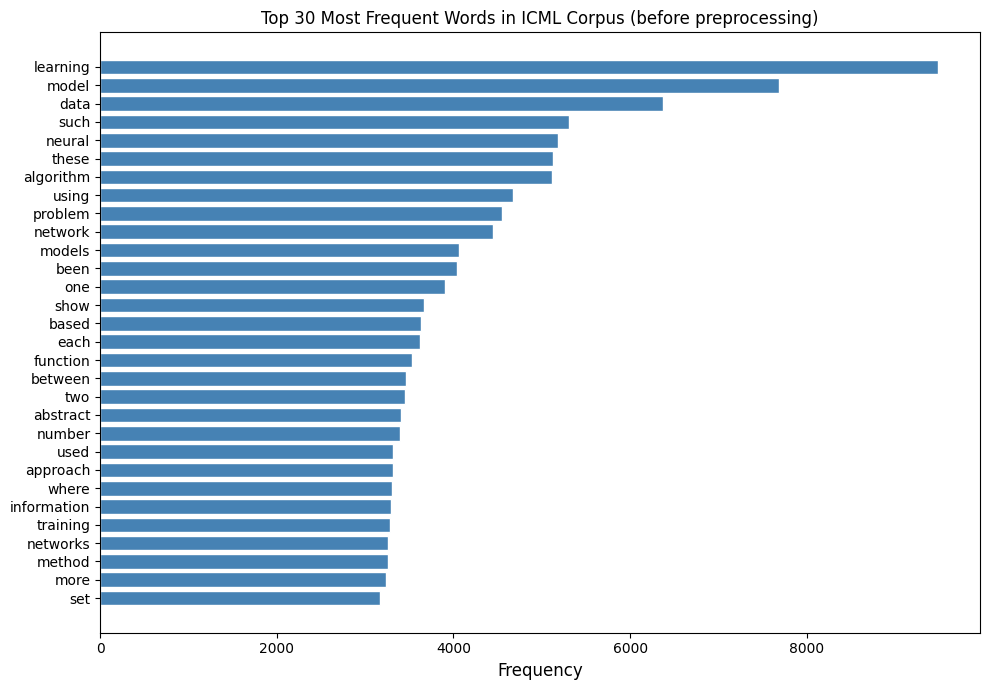

In [58]:
# Plot 3: Top 30 frequent words (before preprocessing)
basic_stops = {
    'the','a','an','of','in','and','to','is','are','for','with','we','this','that',
    'on','by','as','it','be','from','our','can','at','or','not','was','has','have','which','its'
}

word_counts = (
    df['text'].str.lower().str.split().explode()
    .loc[lambda s: s.str.isalpha() & ~s.isin(basic_stops)]
    .value_counts().head(30)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(word_counts.index, word_counts.values, color='steelblue', edgecolor='white')
ax.set_xlabel('Frequency', fontsize=12)
ax.set_title('Top 30 Most Frequent Words in ICML Corpus (before preprocessing)', fontsize=12)

plt.tight_layout()
plt.savefig('eda_top_words.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 1.1 — Section 3: Text Preprocessing for LDA
Steps: lowercase, remove noise, tokenise, stopword removal, lemmatisation, vectorisation.

In [59]:
# Build stopwords (English + common ML filler words)
stop_words = set(stopwords.words('english')) | {
    'paper', 'show', 'result', 'model', 'method', 'use', 'also', 'one', 'two',
    'algorithm', 'propose', 'present', 'approach', 'problem', 'based', 'given',
    'using', 'learn', 'new', 'set', 'data', 'first', 'however', 'section',
    'work', 'note', 'consider', 'function', 'figure', 'table', 'example',
    'let', 'well', 'case', 'therefore', 'thus', 'since', 'many', 'different',
    'see', 'found', 'shown', 'provide', 'make', 'find', 'obtained', 'study',
    'proposed', 'used', 'large', 'small', 'high', 'number', 'known'
}
lemmatizer = WordNetLemmatizer()
def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|\d+|[^\w\s]', ' ', text)
    tokens = nltk.word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens if len(t) >= 3 and t not in stop_words]
    return ' '.join(tokens)

print('Preprocessing text corpus.')
df['processed_text'] = df['text'].apply(preprocess)
print('Preprocessing complete.')

print(f"\nOriginal text sample:\n{df['text'].iloc[5][:200]}")
print(f"\nProcessed text sample:\n{df['processed_text'].iloc[5][:200]}")

Preprocessing text corpus.
Preprocessing complete.

Original text sample:
U sing a neural net to instantiate a deformable model Christopher K. I. Williams; Michael D. Revowand Geoffrey E. Hinton Department of Computer Science, University of Toronto Toronto, Ontario, Canada 

Processed text sample:
sing neural net instantiate deformable christopher williams michael revowand geoffrey hinton department computer science university toronto toronto ontario canada abstract deformable model attractive 


In [60]:
# Build Document-Term Matrix (DTM)
vectorizer = CountVectorizer(max_features=5000, min_df=5, max_df=0.6)
dtm = vectorizer.fit_transform(df['processed_text'])
vocab = vectorizer.get_feature_names_out()

print(f"Document-Term Matrix shape: {dtm.shape}")
print(f"  Documents (rows): {dtm.shape[0]}")
print(f"  Vocabulary size (columns): {dtm.shape[1]}")
print("\nSample vocabulary terms (first 30):")
print(vocab[:30].tolist())

Document-Term Matrix shape: (6560, 5000)
  Documents (rows): 6560
  Vocabulary size (columns): 5000

Sample vocabulary terms (first 30):
['ability', 'able', 'absence', 'absent', 'absolute', 'abstract', 'abstraction', 'abu', 'abundance', 'accelerate', 'accelerated', 'acceleration', 'accept', 'acceptable', 'acceptance', 'accepted', 'access', 'accessible', 'accommodate', 'accompanying', 'accomplish', 'accomplished', 'according', 'accordingly', 'account', 'accounted', 'accounting', 'accumulated', 'accuracy', 'accurate']


---
## 1.1 Section 4: Determining Optimal Model Parameters
LDA models are trained for a range of topic counts (`k`). Perplexity and log-likelihood are used to identify the optimal `k`: perplexity decreases with more topics but eventually flattens (elbow), while log-likelihood increases and then levels off.

In [61]:
topic_range = [5, 7, 10, 12, 15, 18, 20]
perplexities, log_likelihoods = [], []

print('Evaluating models for different numbers of topics...')
print(f"{'k':>4}  {'Perplexity':>12}  {'Log-Likelihood':>15}")
print('-' * 36)

for k in topic_range:
    model = LatentDirichletAllocation(
        n_components=k, max_iter=15, learning_method='online',
        learning_offset=50.0, random_state=42, n_jobs=-1
    ).fit(dtm)

    perp, ll = model.perplexity(dtm), model.score(dtm)
    perplexities.append(perp)
    log_likelihoods.append(ll)
    print(f"{k:>4}  {perp:>12.2f}  {ll:>15.2f}")

Evaluating models for different numbers of topics...
   k    Perplexity   Log-Likelihood
------------------------------------
   5       1565.43      -7437154.13
   7       1521.11      -7408119.16
  10       1500.87      -7394573.93
  12       1497.03      -7391983.86
  15       1476.29      -7377879.54
  18       1453.91      -7362432.72
  20       1465.57      -7370509.80


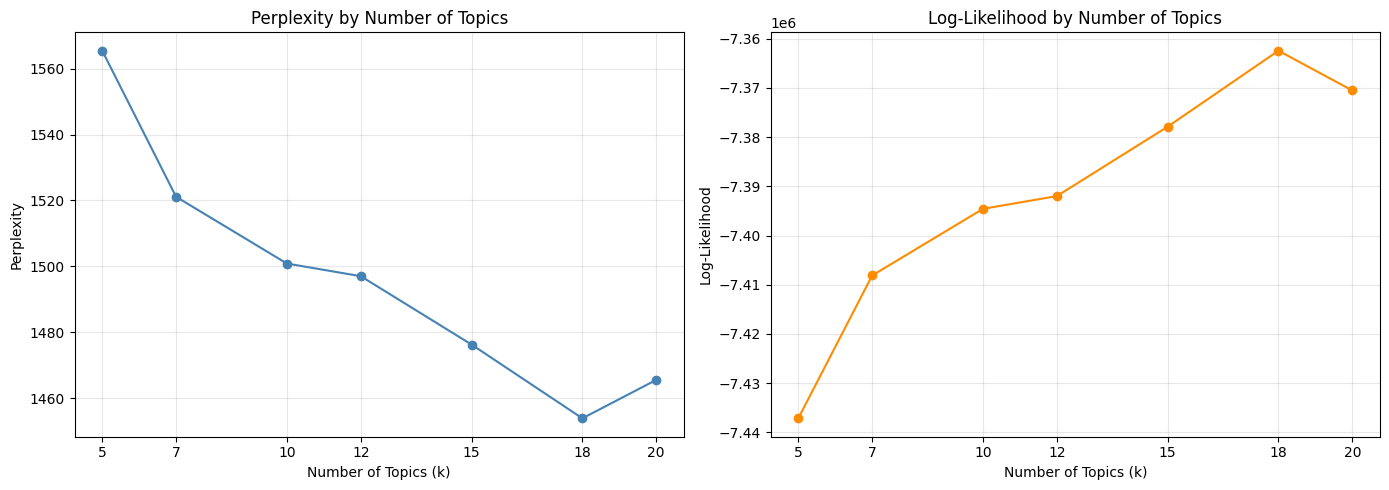


Elbow point: k = 7
Lowest perplexity: k = 18
Selected optimal k: 7


In [62]:
# Plot perplexity and log-likelihood
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(topic_range, perplexities, marker='o', color='steelblue')
axes[0].set_xlabel('Number of Topics (k)')
axes[0].set_ylabel('Perplexity')
axes[0].set_title('Perplexity by Number of Topics')
axes[0].set_xticks(topic_range)
axes[0].grid(True, alpha=0.3)

axes[1].plot(topic_range, log_likelihoods, marker='o', color='darkorange')
axes[1].set_xlabel('Number of Topics (k)')
axes[1].set_ylabel('Log-Likelihood')
axes[1].set_title('Log-Likelihood by Number of Topics')
axes[1].set_xticks(topic_range)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('parameter_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

# Choose the best number of topics
perp_diffs = np.diff(perplexities) * -1
elbow_idx = np.argmax(perp_diffs)
optimal_k = topic_range[elbow_idx + 1]
min_perp_k = topic_range[np.argmin(perplexities)]

print(f"\nElbow point: k = {optimal_k}")
print(f"Lowest perplexity: k = {min_perp_k}")
print(f"Selected optimal k: {optimal_k}")

---
## 1.1 Section 5: Final LDA Model Training

In [63]:
print(f"Training final LDA model with {optimal_k} topics...")

lda_final = LatentDirichletAllocation(
    n_components=optimal_k,
    max_iter=25,
    learning_method='online',
    learning_offset=50.0,
    random_state=42,
    n_jobs=-1
)

lda_final.fit(dtm)
print('Training complete.')

final_perplexity = lda_final.perplexity(dtm)
final_log_lik = lda_final.score(dtm)

print('\nFinal Model Performance:')
print(f'Perplexity: {final_perplexity:.2f}')
print(f'Log-Likelihood: {final_log_lik:.2f}')

Training final LDA model with 7 topics...
Training complete.

Final Model Performance:
Perplexity: 1516.86
Log-Likelihood: -7405286.04


In [64]:
# Print top 10 words per topic
vocab = vectorizer.get_feature_names_out()
n_top = 10

print(f"Top {n_top} keywords per topic:\n")
topic_top_words = []
for i, topic_vec in enumerate(lda_final.components_):
    top_idx   = topic_vec.argsort()[:-n_top - 1:-1]
    top_words = [vocab[j] for j in top_idx]
    topic_top_words.append(top_words)
    print(f"  Topic {i+1:>2}: {', '.join(top_words)}")

Top 10 keywords per topic:

  Topic  1: clustering, structure, word, cluster, language, graph, similarity, sequence, representation, document
  Topic  2: learning, state, time, control, policy, action, dynamic, system, decision, value
  Topic  3: learning, algorithm, bound, classification, training, problem, class, classifier, optimization, error
  Topic  4: image, object, feature, recognition, task, speech, human, model, representation, system
  Topic  5: neuron, cell, signal, system, stimulus, neural, visual, spike, response, information
  Topic  6: network, neural, input, learning, system, output, weight, unit, training, layer
  Topic  7: distribution, model, kernel, parameter, matrix, variable, method, linear, gaussian, inference


## Screenshots of the Key Diagrams

These screenshots summarize the main visual outputs of the workflow:

### EDA: Paper Distribution + Abstract Lengths
![EDA paper distribution](eda_paper_distribution.png)

### EDA: Top Frequent Words
![EDA top words](eda_top_words.png)

### LDA Parameter Tuning
![LDA parameter tuning](parameter_tuning.png)